# 이동평균과 시계열 트렌드 분석

- `rolling()`으로 이동평균(moving average)을 계산해 데이터의 잔물결(noise)을 걷어내고 추세 분석
- 일별 누적 매출(`cumsum()`)을 함께 그려 "하루 단위 변동"과 "누적 추세"를 구분

In [7]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 윈도우 기본 한글 폰트 설정 및 마이너스 기호 깨짐 방지
mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

load_dotenv()

USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


df.head()

C:\Users\soldesk\AppData\Local\Temp\ipykernel_5556\231463285.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
1,2,치킨,치킨,22000,4.8,서초구,2026-08-02
2,3,피자,피자,25000,4.2,강남구,2026-08-03
3,4,짜장면,중식,8000,4.0,송파구,2026-08-04
4,5,마라탕,중식,13000,4.6,강남구,2026-08-05


In [ ]:
daily_sales = df.groupby("ORDER_DATE")["PRICE"].sum()
daily_sales # ORDER_DATE가 index컬럼으로 취급되어 분석하기 위한 접근이 안됨

ORDER_DATE
2026-08-01     9000
2026-08-02    22000
2026-08-03    25000
2026-08-04     8000
2026-08-05    13000
2026-08-06    11000
2026-08-07    18000
2026-08-08    15500
2026-08-09    44000
2026-08-10    46000
2026-08-11    53000
2026-08-12    16500
2026-08-13    31500
2026-08-14    38500
2026-08-15    19000
2026-08-16    14500
2026-08-17    47500
2026-08-18    19500
2026-08-19    42500
2026-08-20    32500
2026-08-21    36000
2026-08-22    14000
Name: PRICE, dtype: int64

In [9]:
# reset_index() 사용 시 ORDER_DATE 옆에 인덱스 번호가 새로 생성되서 ORDER_DATE를 분석하기 위해 접근 가능
daily_sales = df.groupby("ORDER_DATE")["PRICE"].sum().reset_index()
daily_sales.columns = ["ORDER_DATE", "일매출"]
# 바로 직전 3일 치를 묶음(window)으로 삼아서 계산
daily_sales["3일이동평균"] = daily_sales["일매출"].rolling(window=3).mean()
daily_sales["누적매출"] = daily_sales["일매출"].cumsum()

daily_sales.head(10)
# 8-01은 그 앞에 2일치 데이터가 부족해서 NaN값


,ORDER_DATE,일매출,3일이동평균,누적매출
0,2026-08-01,9000,NaN,9000
1,2026-08-02,22000,NaN,31000
2,2026-08-03,25000,18666.666667,56000
3,2026-08-04,8000,18333.333333,64000
4,2026-08-05,13000,15333.333333,77000
5,2026-08-06,11000,10666.666667,88000
6,2026-08-07,18000,14000.000000,106000
7,2026-08-08,15500,14833.333333,121500
8,2026-08-09,44000,25833.333333,165500
9,2026-08-10,46000,35166.666667,211500


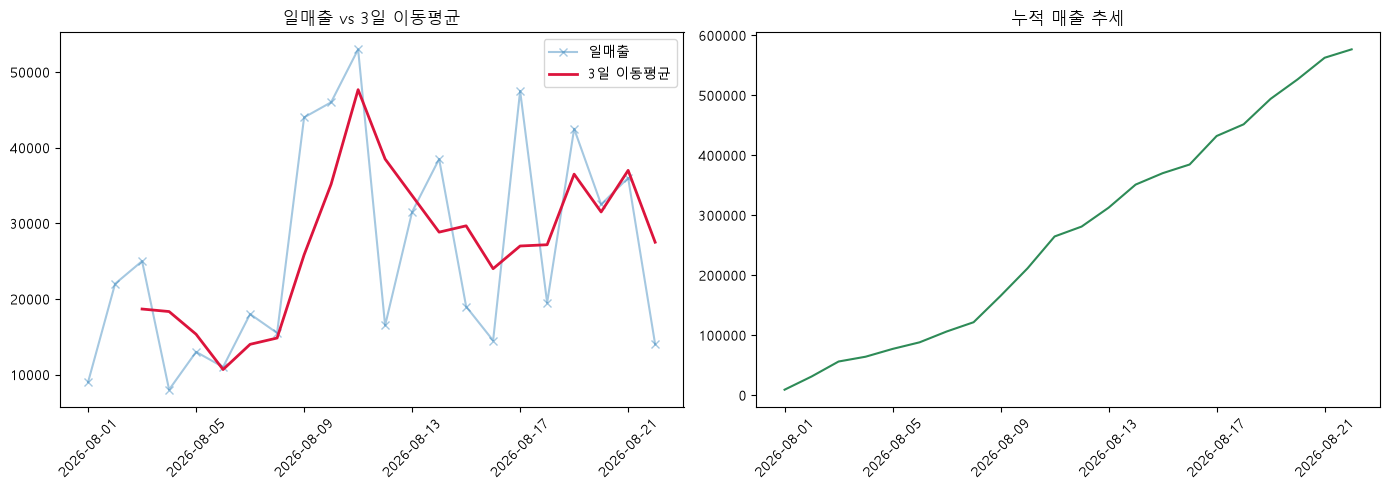

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(daily_sales["ORDER_DATE"], daily_sales["일매출"], label="일매출", alpha=0.4, marker="x")   #alpha : 투명도
axes[0].plot(daily_sales["ORDER_DATE"], daily_sales["3일이동평균"], label="3일 이동평균", linewidth=2, color="crimson",  marker="o")
axes[0].set_title("일매출 vs 3일 이동평균")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(daily_sales["ORDER_DATE"], daily_sales["누적매출"], color="seagreen")
axes[1].set_title("누적 매출 추세")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()